# Light Curve Figure
Panels **a-d**: imaging cutouts (placeholders — drop in your cutout images later).
Panel **e**: main light curve with inset zoom.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.image as mpimg
import json
from astropy.table import Table, Column
from astropy.io import ascii

## Data-reading functions

In [2]:
def read_atlas_forcedphot_file(filename, snr_thresh=5):
    """
    Read ATLAS forced photometry and split into detections and limits
    for o and c filters.
    """

    colnames = [
        "mjd", "m", "dm", "uJy", "duJy", "filter",
        "err", "chiN", "RA", "Dec",
        "x", "y", "maj", "min", "phi",
        "apfit", "mag5sig", "Sky", "Obs"
    ]

    atlas = pd.read_csv(
        filename,
        sep=r"\s+",
        comment="#",
        names=colnames
    )

    # Ensure numeric
    atlas["uJy"] = pd.to_numeric(atlas["uJy"], errors="coerce")
    atlas["duJy"] = pd.to_numeric(atlas["duJy"], errors="coerce")

    # Drop bad rows
    atlas = atlas.dropna(subset=["uJy", "duJy"])

    # Signal-to-noise
    atlas["snr"] = atlas["uJy"] / atlas["duJy"]

    # Detections vs limits
    atlas_dets = atlas[(atlas["snr"] >= snr_thresh) & (atlas["uJy"] > 0)]
    atlas_lims = atlas[atlas["snr"] < snr_thresh]

    atlas_lims = atlas_lims.copy()  # avoid modifying original table
    # atlas_lims['uJy'] = 5 * atlas_lims['duJy']

    # Split by filter
    odets = atlas_dets[atlas_dets["filter"] == "o"]
    cdets = atlas_dets[atlas_dets["filter"] == "c"]

    olims = atlas_lims[atlas_lims["filter"] == "o"]
    clims = atlas_lims[atlas_lims["filter"] == "c"]

    return odets, cdets, olims, clims

In [3]:
def read_ztf_forcedphot_file(filename, use_infobits_flag: bool = True):
    # Read the file
    ztflc = ascii.read(filename, format='basic')

    # Clean column names: remove trailing spaces/commas
    for col in ztflc.colnames:
        new_name = col.strip().strip(',')
        if new_name != col:
            ztflc.rename_column(col, new_name)

    # Filter out bad data if requested
    if use_infobits_flag and 'infobitssci' in ztflc.colnames:
        ztflc = ztflc[ztflc['infobitssci'] == 0]

    # Handle 'null' entries in flux
    if 'forcediffimflux' in ztflc.colnames:
        try:
            np.array(ztflc['forcediffimflux'], dtype=float)
        except ValueError:
            ztflc = ztflc[ztflc['forcediffimflux'] != 'null']

    # Convert JD to float
    ztflc['jd'] = np.array(ztflc['jd'], dtype=float)

    # Convert fluxes to micro-Janskys
    flux_uJy = np.array(ztflc['forcediffimflux'], dtype=float) * \
               10**(-0.4 * (np.array(ztflc['zpmaginpsci']) + 48.6)) / 1e-29
    fluxunc_uJy = np.array(ztflc['forcediffimfluxunc'], dtype=float) * \
                   10**(-0.4 * (np.array(ztflc['zpmaginpsci']) + 48.6)) / 1e-29

    ztflc.add_column(Column(name='forcediffimflux_uJy', data=flux_uJy))
    ztflc.add_column(Column(name='forcediffimfluxunc_uJy', data=fluxunc_uJy))

    # Separate detections (S/N > 5) and upper limits (S/N < 5)
    ztflc_dets = ztflc[flux_uJy / fluxunc_uJy > 5]
    ztflc_lims = ztflc[flux_uJy / fluxunc_uJy < 5].copy()

    # Set upper limits as 5 x flux uncertainty
    ztflc_lims['forcediffimflux_uJy'] = 5 * ztflc_lims['forcediffimfluxunc_uJy']

    # Split by filter
    gdets = ztflc_dets[ztflc_dets['filter'] == 'ZTF_g']
    rdets = ztflc_dets[ztflc_dets['filter'] == 'ZTF_r']
    idets = ztflc_dets[ztflc_dets['filter'] == 'ZTF_i']

    glims = ztflc_lims[ztflc_lims['filter'] == 'ZTF_g']
    rlims = ztflc_lims[ztflc_lims['filter'] == 'ZTF_r']
    ilims = ztflc_lims[ztflc_lims['filter'] == 'ZTF_i']

    return gdets, rdets, idets, glims, rlims, ilims

In [4]:
def read_diff_json(filename, snr_threshold=5):

    # Load JSON
    with open(filename) as f:
        data = json.load(f)

    rows = []

    # Convert dictionary to row list
    for key in data:
        row = data[key]

        rows.append({
            "mjd": row["mjd"],
            "flux": row["psfflux"],
            "flux_unc": row["psfflux_unc"],
            "zp": row["zp"],
            "bandid": row["bandid"]
        })

    tab = Table(rows=rows)

    # Convert flux -> microJy
    flux_uJy = tab["flux"] * 10**(-0.4 * (tab["zp"] + 48.6)) / 1e-29
    fluxunc_uJy = tab["flux_unc"] * 10**(-0.4 * (tab["zp"] + 48.6)) / 1e-29

    tab["flux_uJy"] = flux_uJy
    tab["fluxunc_uJy"] = fluxunc_uJy

    snr = flux_uJy / fluxunc_uJy

    # detections
    dets = tab[snr > snr_threshold]

    # limits
    lims = tab[snr <= snr_threshold].copy()
    lims["flux_uJy"] = snr_threshold * lims["fluxunc_uJy"]

    # split by filter
    f1_dets = dets[dets["bandid"] == 1]
    f2_dets = dets[dets["bandid"] == 2]

    f1_lims = lims[lims["bandid"] == 1]
    f2_lims = lims[lims["bandid"] == 2]

    return f1_dets, f2_dets, f1_lims, f2_lims

## Binning functions

In [42]:
def bin_atlas_by_day(dets, day_width=2.0):
    """
    Bin ATLAS forced photometry into day bins using inverse-variance weighting.

    Parameters
    ----------
    dets : dict
        Dictionary of ATLAS detections keyed by filter.
        Example: {'o': odets, 'c': cdets}
    day_width : float
        Width of time bin in days

    Returns
    -------
    binned : dict
        Dictionary keyed by filter containing mjd, flux, flux_unc
    """

    binned = {}

    for filt, tab in dets.items():

        mjd = np.asarray(tab['mjd'], dtype=float)
        flux = np.asarray(tab['uJy'], dtype=float)
        fluxunc = np.asarray(tab['duJy'], dtype=float)

        day_index = np.floor(mjd / day_width)

        mjd_bins, flux_bins, fluxunc_bins = [], [], []

        for day in np.unique(day_index):
            mask = day_index == day

            if np.sum(mask) == 1:
                mjd_bins.append(mjd[mask][0])
                flux_bins.append(flux[mask][0])
                fluxunc_bins.append(fluxunc[mask][0])
            else:
                w = 1.0 / fluxunc[mask]**2
                f_bin = np.sum(w * flux[mask]) / np.sum(w)
                f_unc = np.sqrt(1.0 / np.sum(w))

                mjd_bins.append(np.mean(mjd[mask]))
                flux_bins.append(f_bin)
                fluxunc_bins.append(f_unc)

        binned[filt] = {
            'mjd': np.array(mjd_bins),
            'flux': np.array(flux_bins),
            'flux_unc': np.array(fluxunc_bins),
        }

    return binned

In [32]:
def bin_atlas_limits_by_day(tab, day_width=1.0, nsigma=5.0):
    mjd = np.asarray(tab['mjd'], dtype=float)
    duJy = np.asarray(tab['duJy'], dtype=float)

    day_index = np.floor(mjd / day_width)

    mjd_bin = []
    fluxlim_bin = []
    duJy_bin = []

    for day in np.unique(day_index):
        mask = day_index == day
        if not np.any(mask):
            continue

        # inverse-variance combination
        ivar = np.sum(1.0 / duJy[mask]**2)
        sigma_bin = np.sqrt(1.0 / ivar)

        mjd_bin.append(np.mean(mjd[mask]))
        duJy_bin.append(sigma_bin)
        fluxlim_bin.append(nsigma * sigma_bin)

    return Table({
        'mjd': mjd_bin,
        'fluxlim_uJy': fluxlim_bin,
        'duJy': duJy_bin,
    })

In [43]:
def bin_by_day_per_filter(dets, zpavg, day_width=2.0):
    """
    Bin ZTF forced-diffim fluxes per filter into day bins
    using inverse-variance weighting after zeropoint rescaling.
    """

    binned = {}

    for filt, tab in dets.items():

        # ---- Time handling ----
        if 'mjd' in tab.colnames:
            mjd = np.asarray(tab['mjd'], dtype=float)
        elif 'jd' in tab.colnames:
            mjd = np.asarray(tab['jd'], dtype=float) - 2400000.5
        else:
            raise KeyError("Table must contain 'jd' or 'mjd'")

        # ---- Flux columns ----
        if 'forcediffimflux_uJy' in tab.colnames:
            flux = np.asarray(tab['forcediffimflux_uJy'], dtype=float)
            fluxunc = np.asarray(tab['forcediffimfluxunc_uJy'], dtype=float)
        elif 'forcediffimflux' in tab.colnames:
            flux = np.asarray(tab['forcediffimflux'], dtype=float)
            fluxunc = np.asarray(tab['forcediffimfluxunc'], dtype=float)
        else:
            raise KeyError("Forced-diffim flux columns not found")

        # ---- Zeropoint column (auto-detect) ----
        zp_col_candidates = [
            'zpdiff',
            'zpdiffim',
            'zpmaginpsci',
            'magzp',
            'zp',
            'magzpsci',
        ]

        zp_col = None
        for col in zp_col_candidates:
            if col in tab.colnames:
                zp_col = col
                break

        if zp_col is None:
            raise KeyError(
                f"No zeropoint column found. Available columns:\n{tab.colnames}"
            )

        zpdiff = np.asarray(tab[zp_col], dtype=float)

        # ---- Zeropoint reference ----
        zp_ref = zpavg[filt] if isinstance(zpavg, dict) else zpavg

        # ---- Zeropoint rescaling ----
        scale = 10.0 ** (0.4 * (zp_ref - zpdiff))
        flux_new = flux * scale
        fluxunc_new = fluxunc * scale

        # ---- Day binning ----
        day_index = np.floor(mjd / day_width)

        mjd_bins, flux_bins, fluxunc_bins = [], [], []

        for day in np.unique(day_index):
            mask = day_index == day

            if np.sum(mask) == 1:
                mjd_bins.append(mjd[mask][0])
                flux_bins.append(flux_new[mask][0])
                fluxunc_bins.append(fluxunc_new[mask][0])
            else:
                w = 1.0 / fluxunc_new[mask]**2
                f_bin = np.sum(w * flux_new[mask]) / np.sum(w)
                f_unc = np.sqrt(1.0 / np.sum(w))

                mjd_bins.append(np.mean(mjd[mask]))
                flux_bins.append(f_bin)
                fluxunc_bins.append(f_unc)

        binned[filt] = {
            'mjd': np.array(mjd_bins),
            'flux': np.array(flux_bins),
            'flux_unc': np.array(fluxunc_bins),
        }

    return binned

In [44]:
def bin_ztf_limits_by_day(lims, day_width=1.0, nsigma=5.0):
    """
    Bin ZTF upper limits into day bins using inverse-variance weighting.
    Works on an Astropy Table with columns 'jd' and 'forcediffimfluxunc_uJy'.

    Returns a dict with arrays: 'mjd', 'fluxlim_uJy', 'fluxunc_uJy'
    """
    mjd = np.asarray(lims['jd'], dtype=float) - 2400000.5
    fluxunc = np.asarray(lims['forcediffimfluxunc_uJy'], dtype=float)

    day_index = np.floor(mjd / day_width)

    mjd_bin, fluxlim_bin, fluxunc_bin = [], [], []

    for day in np.unique(day_index):
        mask = day_index == day
        if not np.any(mask):
            continue

        ivar = np.sum(1.0 / fluxunc[mask]**2)
        sigma_bin = np.sqrt(1.0 / ivar)

        mjd_bin.append(np.mean(mjd[mask]))
        fluxunc_bin.append(sigma_bin)
        fluxlim_bin.append(nsigma * sigma_bin)

    return {
        'mjd': np.array(mjd_bin),
        'fluxlim_uJy': np.array(fluxlim_bin),
        'fluxunc_uJy': np.array(fluxunc_bin),
    }

## Load and bin data
Update file paths below as needed.

In [45]:
# Reference MJD used to center all time axes
mjd_ref = 60267

In [46]:
gdets, rdets, idets, glims, rlims, ilims = read_ztf_forcedphot_file(
    "/Users/ayannamann/Downloads/forcedphotometry_req00450494_lc.txt"
)
odets, cdets, olims, clims = read_atlas_forcedphot_file(
    "/Users/ayannamann/Downloads/ATLAS.txt"
)
f1d, f2d, f1l, f2l = read_diff_json(
    "/Users/ayannamann/Downloads/ZTF23abomysh.diff.json"
)

In [47]:
ztf_dets = {
    'g': gdets,
    'r': rdets,
    'i': idets,
}
zpavg = {
    'g': 26.3,
    'r': 26.5,
    'i': 26.2,
}
ztf_binned = bin_by_day_per_filter(ztf_dets, zpavg, day_width=1.0)

g_bin = ztf_binned['g']
r_bin = ztf_binned['r']
i_bin = ztf_binned['i']

g_mjd_centered = g_bin['mjd'] - mjd_ref
r_mjd_centered = r_bin['mjd'] - mjd_ref
i_mjd_centered = i_bin['mjd'] - mjd_ref

# Bin ZTF upper limits by day
glims_binned = bin_ztf_limits_by_day(glims, day_width=1.0)
rlims_binned = bin_ztf_limits_by_day(rlims, day_width=1.0)
ilims_binned = bin_ztf_limits_by_day(ilims, day_width=1.0)

glims_mjd_centered = glims_binned['mjd'] - mjd_ref
rlims_mjd_centered = rlims_binned['mjd'] - mjd_ref
ilims_mjd_centered = ilims_binned['mjd'] - mjd_ref

In [48]:
atlas_dets = {
    'o': odets,
    'c': cdets,
}

atlas_binned = bin_atlas_by_day(atlas_dets)

o_bin = atlas_binned['o']
c_bin = atlas_binned['c']

o_mjd_centered = o_bin['mjd'] - mjd_ref
c_mjd_centered = c_bin['mjd'] - mjd_ref

# Bin ATLAS upper limits by day
olims_binned = bin_atlas_limits_by_day(olims[olims['duJy'] < 100], day_width=3.0)
clims_binned = bin_atlas_limits_by_day(clims[clims['duJy'] < 100], day_width=3.0)

olims_mjd_centered = np.asarray(olims_binned['mjd']) - mjd_ref
clims_mjd_centered = np.asarray(clims_binned['mjd']) - mjd_ref

In [49]:
# WISE/diff-json centered MJDs
f1d_mjd_centered = f1d['mjd'] - mjd_ref
f2d_mjd_centered = f2d['mjd'] - mjd_ref
f1l_mjd_centered = f1l['mjd'] - mjd_ref
f2l_mjd_centered = f2l['mjd'] - mjd_ref

# SED epoch offsets
sed_hot_day  = 60260.00 - mjd_ref   # highest BB temperature
sed_cool_day = 60292.63 - mjd_ref   # lowest  BB temperature

## Figure layout

- **a, b, c, d** — imaging cutout panels (top row). Replace the placeholder `imshow` calls
  with `mpimg.imread("path/to/cutout.png")` once your cutout images are ready.
- **e** — main light curve panel with an inset zoom, spanning the full figure width.

In [50]:
def plot_lc(ax, ms=7.5):
    """Plot all light curve series into a given axes."""
    EBK = dict(capsize=2, markeredgewidth=0.75)

    # -- Detections --
    ax.errorbar(o_mjd_centered, o_bin['flux']/1e3, yerr=o_bin['flux_unc']/1e3,
                fmt='p', markeredgecolor='black', markersize=ms,
                label='ATLAS o', color='magenta', **EBK)
    ax.errorbar(c_mjd_centered, c_bin['flux']/1e3, yerr=c_bin['flux_unc']/1e3,
                fmt='<', markeredgecolor='black', markersize=ms,
                label='ATLAS c', color='g', **EBK)
    ax.errorbar(g_mjd_centered, g_bin['flux']/1e3, yerr=g_bin['flux_unc']/1e3,
                fmt='*', markeredgecolor='black', markersize=ms,
                label='ZTF g', color='b', **EBK)
    ax.errorbar(r_mjd_centered, r_bin['flux']/1e3, yerr=r_bin['flux_unc']/1e3,
                fmt='o', markeredgecolor='black', markersize=ms,
                label='ZTF r', color='r', **EBK)
    ax.errorbar(f1d_mjd_centered, f1d['flux_uJy']/1e3, yerr=f1d['fluxunc_uJy']/1e3,
                fmt='s', markeredgecolor='black', markersize=ms,
                color='black', ecolor='black', capsize=3, markeredgewidth=0.75,
                label='W1')
    ax.errorbar(f2d_mjd_centered, f2d['flux_uJy']/1e3, yerr=f2d['fluxunc_uJy']/1e3,
                fmt='s', markeredgecolor='black', markersize=ms,
                color='orange', ecolor='orange', capsize=3, markeredgewidth=0.75,
                label='W2')

    # -- Upper limits (binned) --
    ax.errorbar(np.asarray(olims_binned['mjd']) - mjd_ref,
                np.asarray(olims_binned['fluxlim_uJy'])/1e3,
                yerr=np.asarray(olims_binned['fluxlim_uJy'])/1e3 * 0.3,
                fmt='p', uplims=True, mfc='none', mec='magenta', markersize=ms,
                color='magenta', **EBK)
    ax.errorbar(np.asarray(clims_binned['mjd']) - mjd_ref,
                np.asarray(clims_binned['fluxlim_uJy'])/1e3,
                yerr=np.asarray(clims_binned['fluxlim_uJy'])/1e3 * 0.3,
                fmt='<', uplims=True, mfc='none', mec='g', markersize=ms,
                color='g', **EBK)
    ax.errorbar(np.asarray(glims_binned['mjd']) - mjd_ref,
                np.asarray(glims_binned['fluxlim_uJy'])/1e3,
                yerr=np.asarray(glims_binned['fluxlim_uJy'])/1e3 * 0.3,
                fmt='*', uplims=True, mfc='none', mec='b', markersize=ms,
                color='b', **EBK)
    ax.errorbar(np.asarray(rlims_binned['mjd']) - mjd_ref,
                np.asarray(rlims_binned['fluxlim_uJy'])/1e3,
                yerr=np.asarray(rlims_binned['fluxlim_uJy'])/1e3 * 0.3,
                fmt='o', uplims=True, mfc='none', mec='r', markersize=ms,
                color='r', **EBK)
    ax.errorbar(f1l_mjd_centered, f1l['flux_uJy']/1e3,
                yerr=f1l['fluxunc_uJy']/1e3,
                fmt='s', uplims=True, mfc='none', mec='black', markersize=ms,
                color='black', **EBK)
    ax.errorbar(f2l_mjd_centered, f2l['flux_uJy']/1e3,
                yerr=f2l['fluxunc_uJy']/1e3,
                fmt='s', uplims=True, mfc='none', mec='orange', markersize=ms,
                color='orange', **EBK)

    # -- Shaded gap + SED lines --
    ax.axvspan(-20, 5, color='lightgrey', alpha=0.5, zorder=0)
    ax.axvline(sed_hot_day,  color='black', linestyle='--', linewidth=0.9, zorder=1)
    ax.axvline(sed_cool_day, color='black', linestyle='--', linewidth=0.9, zorder=1)
    ax.set_yscale('log')
    ax.grid(alpha=0.3)

In [51]:
# ── Cutout panel placeholders ─────────────────────────────────────────────
# Replace each entry with mpimg.imread("path/to/your_cutout.png") once ready.
cutout_paths = {
    "a": None,   # e.g. "/Users/ayannamann/Downloads/cutout_a.png"
    "b": None,
    "c": None,
    "d": None,
}

cutout_titles = {
    "a": "TBD",
    "b": "TBD",
    "c": "TBD",
    "d": "TBD",
}

def plot_cutout(ax, label, path=None, title=""):
    if path is not None:
        img = mpimg.imread(path)
        ax.imshow(img)
    else:
        # placeholder box so the panel layout can be checked before
        # the real cutout images are dropped in
        ax.set_facecolor("0.92")
        ax.text(0.5, 0.5, "cutout\nplaceholder", ha="center", va="center",
                fontsize=8, color="0.5", transform=ax.transAxes)

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("black")

    ax.set_title(title, fontsize=9)
    ax.text(-0.05, 1.05, label, transform=ax.transAxes,
            fontsize=13, fontweight="bold", va="bottom", ha="right")

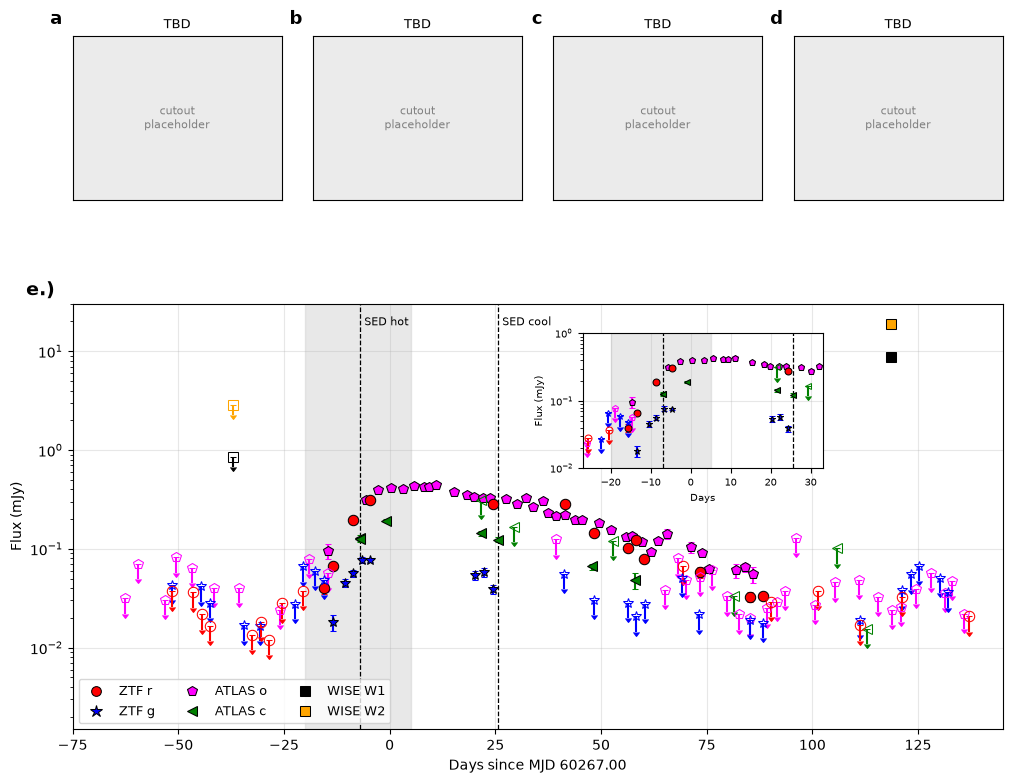

In [52]:
# ── Figure: a-d cutouts (top row) + e main light curve w/ inset (bottom) ──
fig = plt.figure(figsize=(12, 9), dpi=100)
gs = fig.add_gridspec(2, 4, height_ratios=[1, 2.6], hspace=0.35, wspace=0.15)

# -- Panels a, b, c, d --
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[0, 2])
ax_d = fig.add_subplot(gs[0, 3])

for label, ax in zip("abcd", [ax_a, ax_b, ax_c, ax_d]):
    plot_cutout(ax, label, path=cutout_paths[label], title=cutout_titles[label])

# -- Panel e: main light curve, spans full width --
ax_e = fig.add_subplot(gs[1, :])

# Inset zoom, placed inside ax_e in figure-fraction coords
axins = fig.add_axes([0.55, 0.4, 0.2, 0.15])

plot_lc(ax_e, ms=7.5)
plot_lc(axins, ms=5.0)

# -- Main panel formatting --
# ax_e.set_xlim(-55, 145)
ax_e.set_xlim(-75, 145)

ax_e.set_xlabel(f"Days since MJD {mjd_ref:.2f}")
ax_e.set_ylabel("Flux (mJy)")
ax_e.set_title("e.)", loc="left", x=-0.05, fontdict={"fontsize": 14, "fontweight": "bold"})

# SED labels just inside the top of ax_e
trans = ax_e.get_xaxis_transform()
ax_e.text(sed_hot_day  + 1, 0.97, "SED hot",  transform=trans, fontsize=8, va="top", ha="left")
ax_e.text(sed_cool_day + 1, 0.97, "SED cool", transform=trans, fontsize=8, va="top", ha="left")

# -- Color-coded legend --
legend_handles = [
    mlines.Line2D([], [], color='r',       marker='o', linestyle='None',
                  markeredgecolor='black', markeredgewidth=0.75, markersize=7, label='ZTF r'),
    mlines.Line2D([], [], color='b',       marker='*', linestyle='None',
                  markeredgecolor='black', markeredgewidth=0.75, markersize=9, label='ZTF g'),
    mlines.Line2D([], [], color='magenta', marker='p', linestyle='None',
                  markeredgecolor='black', markeredgewidth=0.75, markersize=7, label='ATLAS o'),
    mlines.Line2D([], [], color='g',       marker='<', linestyle='None',
                  markeredgecolor='black', markeredgewidth=0.75, markersize=7, label='ATLAS c'),
    mlines.Line2D([], [], color='black',   marker='s', linestyle='None',
                  markeredgecolor='black', markeredgewidth=0.75, markersize=7, label='WISE W1'),
    mlines.Line2D([], [], color='orange',  marker='s', linestyle='None',
                  markeredgecolor='black', markeredgewidth=0.75, markersize=7, label='WISE W2'),
]
ax_e.legend(handles=legend_handles, framealpha=0.8, fontsize=9, loc='lower left', ncol=3)

# -- Inset formatting --
axins.set_xlim(-27, 33)
axins.set_ylim(10e-3, 1)
axins.tick_params(labelsize=7)
axins.set_xlabel('Days', fontsize=7)
axins.set_ylabel('Flux (mJy)', fontsize=7)

plt.savefig("light_curve_figure.pdf", bbox_inches="tight")
plt.show()